<a href="https://colab.research.google.com/github/abdallhraghad39-code/Superstore_Sales_Analysis/blob/main/%20notebook/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Load Data**




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("/content/Superstore.csv")
sales = pd.read_csv(DATA_PATH, encoding="latin1")
print("First 5 rows:")
print(sales.head())

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

# **2. Inspect Data**

In [4]:
print("\nLast 5 rows:")
print(sales.tail())

print("\nData types:")
print(sales.dtypes)

print("\nMissing values:")
print(sales.isnull().sum())

print("\nSummary statistics:")
print(sales.describe())

print("\nShape:")
print(sales.shape)

print("\nColumns:")
print(sales.columns)

print("\nInfo:")
print(sales.info())

print("\nDuplicate Rows:")
print(sales.duplicated().sum())


Last 5 rows:
      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
9989    9990  CA-2014-110422  1/21/2014  1/23/2014    Second Class   
9990    9991  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9991    9992  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9992    9993  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9993    9994  CA-2017-119914   5/4/2017   5/9/2017    Second Class   

     Customer ID     Customer Name   Segment        Country         City  ...  \
9989    TB-21400  Tom Boeckenhauer  Consumer  United States        Miami  ...   
9990    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9991    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9992    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9993    CC-12220      Chris Cortes  Consumer  United States  Westminster  ...   

     Postal Code  Region       Product ID         Category Sub-Category  \
998

# **3. Convert Data Type**

In [5]:
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    errors="coerce"
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    errors="coerce"
)

# Check if any dates failed to convert
print("\nInvalid Order Dates:")
print(sales["Order Date"].isna().sum())

print("\nInvalid Ship Dates:")
print(sales["Ship Date"].isna().sum())


Invalid Order Dates:
0

Invalid Ship Dates:
0


# **4. Data Cleaning**

In [6]:
# Rounding
sales["Profit"] = sales["Profit"].round(2)
sales["Sales"] = sales["Sales"].round(2)

# Drop Columns
sales = sales.drop(columns = ["Row ID"])

# Check duplicates AFTER dropping Row ID
print("\nDuplicates after dropping Row ID:")
print(sales.duplicated().sum())

duplicate_rows = sales[sales.duplicated(keep=False)]

print("\nDuplicate rows for inspection:")
print(duplicate_rows)



Duplicates after dropping Row ID:
1

Duplicate rows for inspection:
            Order ID Order Date  Ship Date       Ship Mode Customer ID  \
3405  US-2014-150119 2014-04-23 2014-04-27  Standard Class    LB-16795   
3406  US-2014-150119 2014-04-23 2014-04-27  Standard Class    LB-16795   

       Customer Name      Segment        Country      City State  Postal Code  \
3405  Laurel Beltran  Home Office  United States  Columbus  Ohio        43229   
3406  Laurel Beltran  Home Office  United States  Columbus  Ohio        43229   

     Region       Product ID   Category Sub-Category  \
3405   East  FUR-CH-10002965  Furniture       Chairs   
3406   East  FUR-CH-10002965  Furniture       Chairs   

                                           Product Name   Sales  Quantity  \
3405  Global Leather Highback Executive Chair with P...  281.37         2   
3406  Global Leather Highback Executive Chair with P...  281.37         2   

      Discount  Profit  
3405       0.3  -12.06  
3406       0.

In [7]:
# IMPORTANT:
# Do not delete duplicates blindly.
# If you confirm that they are accidental duplicates,
# uncomment the following line:

sales = sales.drop_duplicates()


# **5. Cleaning Validation**

In [8]:
print("\n===== CLEANING VALIDATION =====")

# Missing values
print("\nMissing Values:")
print(sales.isnull().sum())

# Business Rule:
# Ship Date should not be earlier than Order Date

invalid_shipping = (
    sales["Ship Date"] < sales["Order Date"]
).sum()

print("\nShip Date before Order Date:")
print(invalid_shipping)

# Check Sales
negative_sales = (sales["Sales"] < 0).sum()

print("\nNegative Sales:")
print(negative_sales)

# Check Quantity
invalid_quantity = (sales["Quantity"] <= 0).sum()

print("\nInvalid Quantity:")
print(invalid_quantity)

# Check Discount Range
invalid_discount = (
    (sales["Discount"] < 0) |
    (sales["Discount"] > 1)
).sum()

print("\nInvalid Discount:")
print(invalid_discount)


===== CLEANING VALIDATION =====

Missing Values:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Ship Date before Order Date:
0

Negative Sales:
0

Invalid Quantity:
0

Invalid Discount:
0


# **6. Feature Engineering**

In [9]:
print("\n===== FEATURE ENGINEERING =====")


# Order Year
sales["Order Year"] = sales["Order Date"].dt.year


# Order Month Number
sales["Order Month"] = sales["Order Date"].dt.month


# Order Month Name
sales["Month Name"] = sales["Order Date"].dt.month_name()


# Quarter
sales["Order Quarter"] = sales["Order Date"].dt.quarter


# Year-Month for monthly trends
sales["Year Month"] = sales["Order Date"].dt.to_period("M")


# Shipping Days
sales["Shipping Days"] = (
    sales["Ship Date"] - sales["Order Date"]
).dt.days


# Sales Level using NumPy
sales["Sales Level"] = np.where(
    sales["Sales"] > 100,
    "High",
    "Low"
)


print(
    sales[
        [
            "Order Date",
            "Order Year",
            "Order Month",
            "Month Name",
            "Order Quarter",
            "Year Month",
            "Shipping Days",
            "Sales Level"
        ]
    ].head()
)


===== FEATURE ENGINEERING =====
  Order Date  Order Year  Order Month Month Name  Order Quarter Year Month  \
0 2016-11-08        2016           11   November              4    2016-11   
1 2016-11-08        2016           11   November              4    2016-11   
2 2016-06-12        2016            6       June              2    2016-06   
3 2015-10-11        2015           10    October              4    2015-10   
4 2015-10-11        2015           10    October              4    2015-10   

   Shipping Days Sales Level  
0              3        High  
1              3        High  
2              4         Low  
3              7        High  
4              7         Low  


# **7. Filtering**

In [10]:
profit = sales[sales["Profit"] > 0]
loss = sales[sales["Profit"] < 0]
zero_profit = sales[sales["Profit"] == 0]

print("\nProfitable Rows:", len(profit))
print("Loss Rows:", len(loss))
print("Zero Profit Rows:", len(zero_profit))


Profitable Rows: 8058
Loss Rows: 1870
Zero Profit Rows: 65


# **8. Sales Summary**

In [11]:
# Total Sales
Total_sales = sales["Sales"].sum()
# Total Profit
Total_profit = sales["Profit"].sum()
# Total Quantity
Total_quantity = sales["Quantity"].sum()
# Average Sales
Average_Sales = sales["Sales"].mean()
# Count of order id
Count_order_id = sales["Order ID"].nunique()
# Total Discount
Total_Discount = sales["Discount"].sum()

print("\n===== SALES SUMMARY =====")
print("Total Sales:", round(Total_sales, 2))
print("Total Profit:", round(Total_profit, 2))
print("Total Quantity:", Total_quantity)
print("Average Sales:", round(Average_Sales, 2))
print("Count of Order ID:", Count_order_id)
print("Total Discount:", round(Total_Discount, 2))


===== SALES SUMMARY =====
Total Sales: 2296919.28
Total Profit: 286408.6
Total Quantity: 37871
Average Sales: 229.85
Count of Order ID: 5009
Total Discount: 1560.79


# **9. Sales Statistics**

In [12]:
sales_values = sales["Sales"].values

print("Mean:", np.mean(sales_values))
print("Median:", np.median(sales_values))
print("Maximum:", np.max(sales_values))
print("Minimum:", np.min(sales_values))
print("Standard Deviation:", np.std(sales_values))

# Sales Level Analysis
sales_level_analysis = (
    sales.groupby("Sales Level")
    .agg(
        Average_Sales=("Sales", "mean"),
        Average_Profit=("Profit", "mean"),
        Transactions=("Order ID", "count")
    )
)

print("\nSales Level Analysis:")
print(sales_level_analysis)


Mean: 229.85282497748423
Median: 54.48
Maximum: 22638.48
Minimum: 0.44
Standard Deviation: 623.2448910929849

Sales Level Analysis:
             Average_Sales  Average_Profit  Transactions
Sales Level                                             
High            558.204115       67.232779          3764
Low              31.439876        5.353094          6229


# **10. Category Analysis**

In [13]:
category_analysis = (
    sales.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
)


# Profit Margin
category_analysis["Profit Margin %"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Sales"]
) * 100


category_analysis = (
    category_analysis
    .sort_values("Total_Sales", ascending=False)
)


print("\n===== CATEGORY ANALYSIS =====")
print(category_analysis.round(2))



===== CATEGORY ANALYSIS =====
                 Total_Sales  Total_Profit  Total_Quantity  Orders  \
Category                                                             
Technology         836154.02     145455.44            6939    1544   
Furniture          741718.36      18463.16            8026    1764   
Office Supplies    719046.90     122490.00           22906    3742   

                 Profit Margin %  
Category                          
Technology                 17.40  
Furniture                   2.49  
Office Supplies            17.04  


# **11. Sales by Region**

In [14]:
region_analysis = (
    sales.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)


region_analysis["Profit Margin %"] = (
    region_analysis["Total_Profit"]
    / region_analysis["Total_Sales"]
) * 100


region_analysis = (
    region_analysis
    .sort_values("Total_Sales", ascending=False)
)


print("\n===== REGION ANALYSIS =====")
print(region_analysis.round(2))


===== REGION ANALYSIS =====
         Total_Sales  Total_Profit  Orders  Profit Margin %
Region                                                     
West       725457.76     108418.31    1611            14.94
East       678499.93      91534.56    1401            13.49
Central    501239.76      39706.24    1175             7.92
South      391721.83      46749.49     822            11.93


# **12. Sales by Segment**

In [15]:
segment_analysis = (
    sales.groupby("Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)


segment_analysis["Profit Margin %"] = (
    segment_analysis["Total_Profit"]
    / segment_analysis["Total_Sales"]
) * 100


segment_analysis = (
    segment_analysis
    .sort_values("Total_Sales", ascending=False)
)


print("\n===== SEGMENT ANALYSIS =====")
print(segment_analysis.round(2))


===== SEGMENT ANALYSIS =====
             Total_Sales  Total_Profit  Orders  Profit Margin %
Segment                                                        
Consumer      1161401.12     134118.64    2586            11.55
Corporate      706146.32      91979.13    1514            13.03
Home Office    429371.84      60310.83     909            14.05


# **13. Sub-Category Analysis**

In [16]:
sub_category_analysis = (
    sales.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)


sub_category_analysis["Profit Margin %"] = (
    sub_category_analysis["Total_Profit"]
    / sub_category_analysis["Total_Sales"]
) * 100


sub_category_analysis = (
    sub_category_analysis
    .sort_values("Total_Sales", ascending=False)
)


print("\n===== SUB-CATEGORY ANALYSIS =====")
print(sub_category_analysis.round(2))



===== SUB-CATEGORY ANALYSIS =====
              Total_Sales  Total_Profit  Orders  Profit Margin %
Sub-Category                                                    
Phones          330007.10      44516.06     814            13.49
Chairs          328167.73      26602.14     576             8.11
Storage         223843.59      21278.90     777             9.51
Tables          206965.53     -17725.57     307            -8.56
Binders         203412.68      30221.48    1316            14.86
Machines        189238.60       3384.72     112             1.79
Accessories     167380.31      41936.78     718            25.05
Copiers         149528.01      55617.88      68            37.20
Bookcases       114879.98      -3472.59     224            -3.02
Appliances      107532.14      18137.99     451            16.87
Furnishings      91705.12      13059.18     877            14.24
Paper            78479.24      34053.11    1191            43.39
Supplies         46673.52      -1189.08     187        

# **14. Top 10 States By Sales**

In [17]:
top_10_states_by_sales = (
    sales.groupby("State")["Sales"]
    .sum()
    .nlargest(10)
)


print("\n===== TOP 10 STATES BY SALES =====")
print(top_10_states_by_sales)



===== TOP 10 STATES BY SALES =====
State
California      457687.62
New York        310876.20
Texas           170187.91
Washington      138641.29
Pennsylvania    116511.98
Florida          89473.68
Illinois         80166.11
Ohio             77976.82
Michigan         76269.61
Virginia         70636.72
Name: Sales, dtype: float64


# **15. Profitability Analysis**

In [18]:
profitability_analysis = (
    sales.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)


profitability_analysis["Profit Margin %"] = (
    profitability_analysis["Total_Profit"]
    / profitability_analysis["Total_Sales"]
) * 100


profitability_analysis = (
    profitability_analysis
    .sort_values("Profit Margin %", ascending=False)
)


print("\n===== PROFITABILITY ANALYSIS =====")
print(profitability_analysis.round(2))


===== PROFITABILITY ANALYSIS =====
                 Total_Sales  Total_Profit  Profit Margin %
Category                                                   
Technology         836154.02     145455.44            17.40
Office Supplies    719046.90     122490.00            17.04
Furniture          741718.36      18463.16             2.49


# **16. Discount Analysis**

In [19]:
discount_analysis = (
    sales.groupby("Discount")
    .agg(
        Average_Profit=("Profit", "mean"),
        Total_Profit=("Profit", "sum"),
        Total_Sales=("Sales", "sum"),
        Transactions=("Order ID", "count")
    )
    .reset_index()
)


print("\n===== DISCOUNT ANALYSIS =====")
print(discount_analysis.round(2))


# Discount Analysis by Category
discount_by_category = (
    sales.groupby(["Category", "Discount"])
    .agg(
        Average_Profit=("Profit", "mean"),
        Total_Profit=("Profit", "sum"),
        Total_Sales=("Sales", "sum")
    )
    .reset_index()
)


print("\n===== DISCOUNT BY CATEGORY =====")
print(discount_by_category.round(2))


# Correlation - association only, not causation
discount_profit_corr = sales["Discount"].corr(
    sales["Profit"]
)


print("\nDiscount-Profit Correlation:")
print(round(discount_profit_corr, 3))



===== DISCOUNT ANALYSIS =====
    Discount  Average_Profit  Total_Profit  Total_Sales  Transactions
0       0.00           66.90     320987.01   1087908.47          4798
1       0.10           96.06       9029.21     54369.30            94
2       0.15           27.29       1418.98     27558.53            52
3       0.20           24.70      90337.62    764594.28          3657
4       0.30          -45.83     -10357.26    102945.30           226
5       0.32          -88.56      -2391.16     14493.45            27
6       0.40         -111.93     -23057.06    116417.83           206
7       0.45         -226.65      -2493.12      5484.98            11
8       0.50         -310.70     -20506.49     58918.53            66
9       0.60          -43.08      -5944.62      6644.68           138
10      0.70          -95.87     -40075.40     40620.25           418
11      0.80         -101.80     -30539.11     16963.68           300

===== DISCOUNT BY CATEGORY =====
           Category  Disc

# **17. Seasonality Analysis**

In [20]:
monthly_sales = (
    sales.groupby("Year Month")["Sales"]
    .sum()
)


print("\n===== MONTHLY SALES =====")
print(monthly_sales)


# Sales by Month Name
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]


sales_by_month = (
    sales.groupby("Month Name")["Sales"]
    .sum()
    .reindex(month_order)
)


print("\n===== SALES BY MONTH =====")
print(sales_by_month)


# Sales by Year
sales_by_year = (
    sales.groupby("Order Year")["Sales"]
    .sum()
)


print("\n===== SALES BY YEAR =====")
print(sales_by_year)


# Sales by Quarter
sales_by_quarter = (
    sales.groupby("Order Quarter")["Sales"]
    .sum()
)


print("\n===== SALES BY QUARTER =====")
print(sales_by_quarter)


===== MONTHLY SALES =====
Year Month
2014-01     14236.90
2014-02      4519.92
2014-03     55691.02
2014-04     28013.98
2014-05     23648.27
2014-06     34595.12
2014-07     33946.37
2014-08     27909.47
2014-09     81777.32
2014-10     31453.37
2014-11     78628.73
2014-12     69545.63
2015-01     18174.08
2015-02     11951.40
2015-03     38726.26
2015-04     34195.25
2015-05     30131.72
2015-06     24797.30
2015-07     28765.30
2015-08     36898.31
2015-09     64595.87
2015-10     31404.90
2015-11     75972.49
2015-12     74919.51
2016-01     18542.52
2016-02     22978.82
2016-03     51715.85
2016-04     38750.02
2016-05     56987.75
2016-06     40344.52
2016-07     39261.98
2016-08     31115.35
2016-09     73410.07
2016-10     59687.79
2016-11     79412.01
2016-12     96999.06
2017-01     43971.37
2017-02     20301.12
2017-03     58872.35
2017-04     36521.51
2017-05     44261.08
2017-06     52981.70
2017-07     45264.42
2017-08     63120.85
2017-09     87866.64
2017-10     77776

# **18. Shipping Performance**

In [21]:
shipping_analysis = (
    sales.groupby("Ship Mode")
    .agg(
        Average_Shipping_Days=("Shipping Days", "mean"),
        Orders=("Order ID", "nunique"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values(
        "Average_Shipping_Days"
    )
)


print("\n===== SHIPPING PERFORMANCE =====")
print(shipping_analysis.round(2))


# Shipping performance by Region
shipping_by_region = (
    sales.groupby("Region")
    .agg(
        Average_Shipping_Days=("Shipping Days", "mean"),
        Orders=("Order ID", "nunique")
    )
    .sort_values(
        "Average_Shipping_Days"
    )
)


print("\n===== SHIPPING BY REGION =====")
print(shipping_by_region.round(2))


===== SHIPPING PERFORMANCE =====
                Average_Shipping_Days  Orders  Total_Sales  Total_Profit
Ship Mode                                                               
Same Day                         0.04     264    128363.09      15891.77
First Class                      2.18     787    351428.32      48969.74
Second Class                     3.24     964    459193.40      57446.30
Standard Class                   5.01    2994   1357934.47     164100.79

===== SHIPPING BY REGION =====
         Average_Shipping_Days  Orders
Region                                
East                      3.91    1401
West                      3.93    1611
South                     3.96     822
Central                   4.06    1175


# **19. Sales by category Visualization**

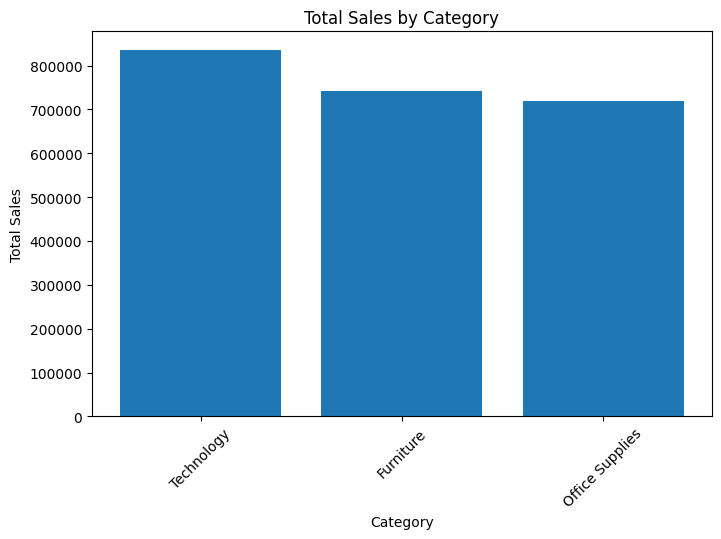

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["Total_Sales"]
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.xticks(rotation=45)
plt.savefig("sales_by_category.png")
plt.show()

# **20. Profit By Category Visualization**

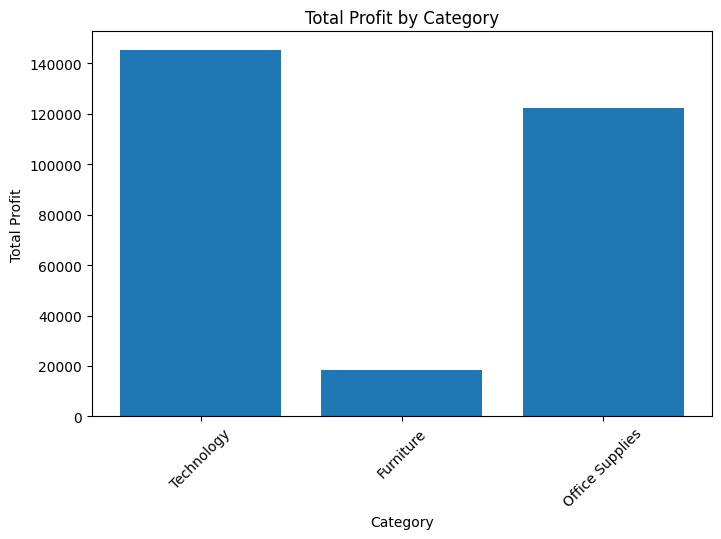

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["Total_Profit"]
)

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.title("Total Profit by Category")
plt.xticks(rotation=45)
plt.savefig("profit_by_category.png")
plt.show()

# **21. Sales By Region Visualization**

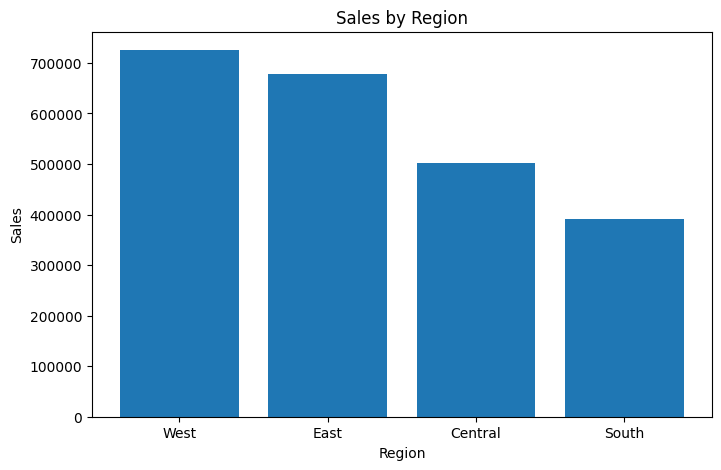

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(region_analysis.index, region_analysis["Total_Sales"])
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sales by Region")
plt.savefig("sales_by_region.png")
plt.show()

# **22. Sales Distribution**

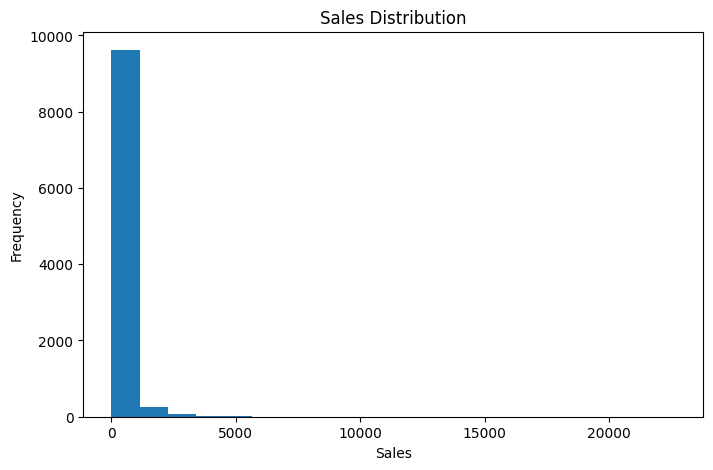

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(sales["Sales"], bins=20)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.savefig("sales_distribution.png")
plt.show()

# **23. Quantity vs Sales**

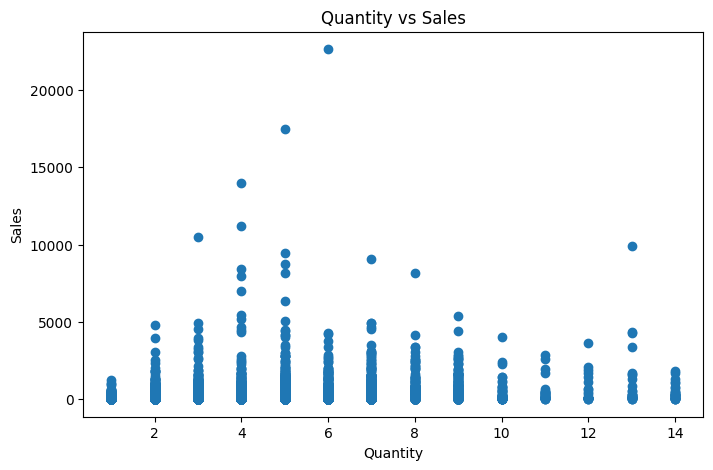

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(sales["Quantity"], sales["Sales"])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.savefig("quantity_vs_sales.png")
plt.show()

# **24. Monthly Sales Trend**

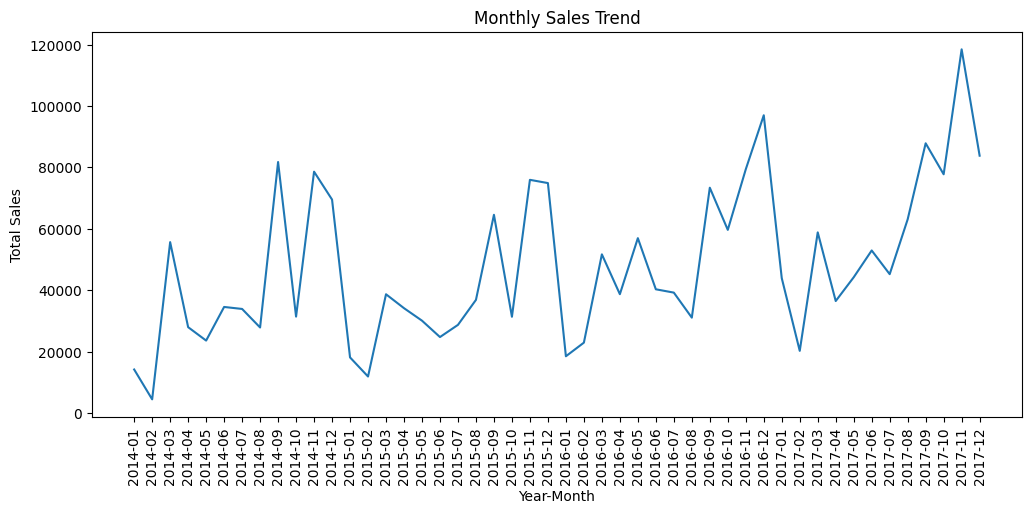

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(
    rotation=90
)
plt.savefig("monthly_sales_trend.png")
plt.show()

# **25. Sales by Month**

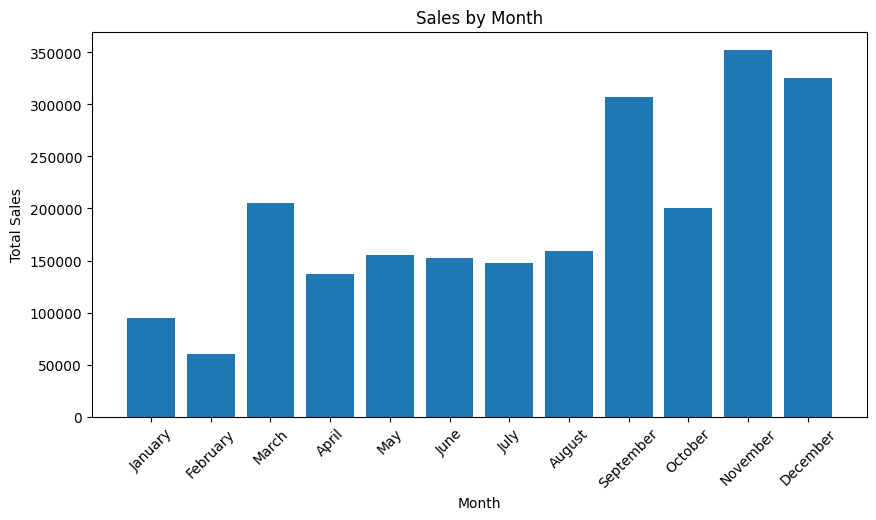

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    sales_by_month.index,
    sales_by_month.values
)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Sales by Month")
plt.xticks(rotation=45)
plt.savefig("sales_by_month.png")
plt.show()

# **26. Top 10 States**

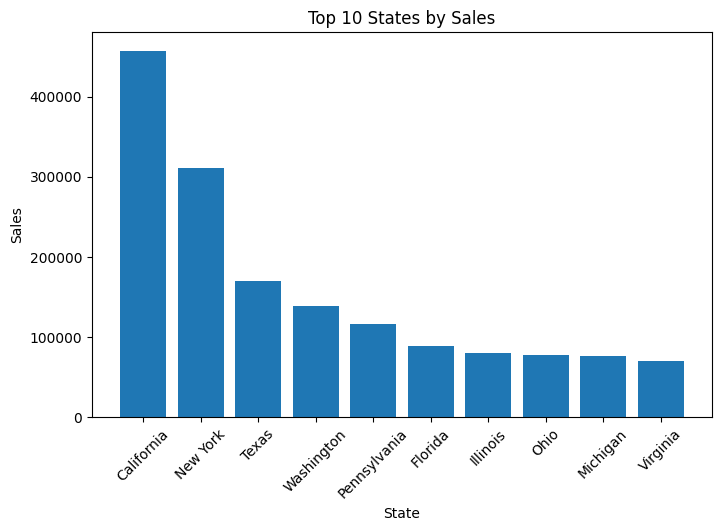

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(top_10_states_by_sales.index, top_10_states_by_sales.values)
plt.xlabel("State")
plt.ylabel("Sales")
plt.title("Top 10 States by Sales")
plt.xticks(rotation=45)
plt.savefig("top_10_states_by_sales.png")
plt.show()

# **27. Discount vs Average Profit**

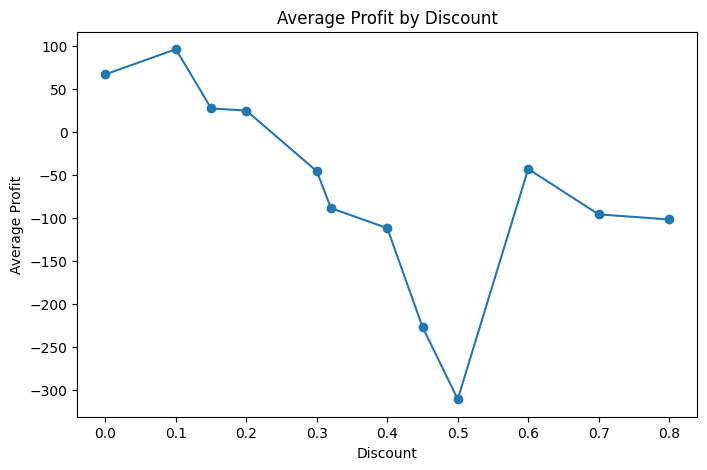

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    discount_analysis["Discount"],
    discount_analysis["Average_Profit"],
    marker="o"
)
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.title("Average Profit by Discount")
plt.savefig("discount_vs_profit.png")
plt.show()

# **28. Average Shipping Days by Ship Mode**

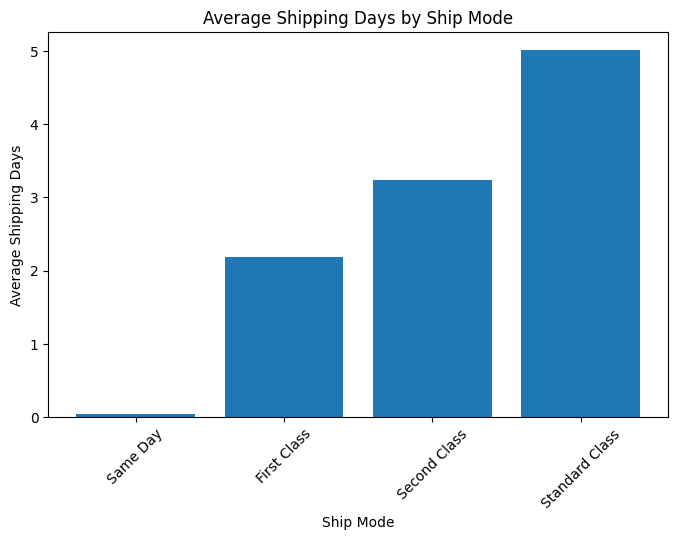

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(
    shipping_analysis.index,
    shipping_analysis["Average_Shipping_Days"]
)

plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.title("Average Shipping Days by Ship Mode")
plt.xticks(rotation=45)
plt.savefig("shipping_performance.png")
plt.show()

# **29. Business Insights**

In [32]:
# Highest Sales Category
highest_sales_category = (
    category_analysis["Total_Sales"].idxmax()
)

highest_sales_value = (
    category_analysis["Total_Sales"].max()
)


print(
    f"1. {highest_sales_category} generated the highest "
    f"sales at ${highest_sales_value:,.2f}."
)


# Highest Profit Category
highest_profit_category = (
    category_analysis["Total_Profit"].idxmax()
)

highest_profit_value = (
    category_analysis["Total_Profit"].max()
)


print(
    f"2. {highest_profit_category} generated the highest "
    f"profit at ${highest_profit_value:,.2f}."
)


# Most Profitable Category by Margin
highest_margin_category = (
    profitability_analysis["Profit Margin %"].idxmax()
)

highest_margin_value = (
    profitability_analysis["Profit Margin %"].max()
)


print(
    f"3. {highest_margin_category} has the highest "
    f"profit margin at {highest_margin_value:.2f}%."
)


# Highest Sales Region
highest_sales_region = (
    region_analysis["Total_Sales"].idxmax()
)

highest_region_sales = (
    region_analysis["Total_Sales"].max()
)


print(
    f"4. {highest_sales_region} is the highest-selling "
    f"region with ${highest_region_sales:,.2f} in sales."
)


# Highest Sales Month
highest_month = sales_by_month.idxmax()

highest_month_sales = sales_by_month.max()


print(
    f"5. {highest_month} recorded the highest total "
    f"sales across the dataset at ${highest_month_sales:,.2f}."
)


# Fastest Ship Mode
fastest_ship_mode = (
    shipping_analysis["Average_Shipping_Days"].idxmin()
)

fastest_shipping_days = (
    shipping_analysis["Average_Shipping_Days"].min()
)


print(
    f"6. {fastest_ship_mode} has the shortest average "
    f"shipping time at {fastest_shipping_days:.2f} days."
)


# Correlation Insight
print(
    f"7. The correlation between Discount and Profit "
    f"is {discount_profit_corr:.3f}. "
    f"This represents an association, not proof of causation."
)

1. Technology generated the highest sales at $836,154.02.
2. Technology generated the highest profit at $145,455.44.
3. Technology has the highest profit margin at 17.40%.
4. West is the highest-selling region with $725,457.76 in sales.
5. November recorded the highest total sales across the dataset at $352,461.03.
6. Same Day has the shortest average shipping time at 0.04 days.
7. The correlation between Discount and Profit is -0.219. This represents an association, not proof of causation.


# **30. Final Validation**

In [33]:
print("\n===== FINAL VALIDATION =====")

print("\nMissing values: ")
print(sales.isnull().sum())

print("\nDuplicate rows: ")
print(sales.duplicated().sum().sum())

print("\nShape: ")
print(sales.shape)

print("\nData types: ")
print(sales.dtypes)

print("\nInvalid Shipping Dates:")
print(
    (
        sales["Ship Date"]
        < sales["Order Date"]
    ).sum()
)

print("\nNegative Sales:")
print(
    (sales["Sales"] < 0).sum()
)


print("\nInvalid Quantity:")
print(
    (sales["Quantity"] <= 0).sum()
)


print("\nInvalid Discount:")
print(
    (
        (sales["Discount"] < 0)
        |
        (sales["Discount"] > 1)
    ).sum()
)


===== FINAL VALIDATION =====

Missing values: 
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order Year       0
Order Month      0
Month Name       0
Order Quarter    0
Year Month       0
Shipping Days    0
Sales Level      0
dtype: int64

Duplicate rows: 
0

Shape: 
(9993, 27)

Data types: 
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region              

# **31. Save Cleaned Data**

In [34]:
OUTPUT_PATH = Path(
    "/content/Superstore_cleaned.csv"
)

sales.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    "\nCleaned dataset saved successfully:",
    OUTPUT_PATH
)


Cleaned dataset saved successfully: /content/Superstore_cleaned.csv
